In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import utils

from statsmodels.tsa.arima.model import ARIMA
from external.api_repo.generators import *
from external.api_repo.utils import *
from pmdarima.arima import ndiffs
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error
from torchmetrics.functional.regression import continuous_ranked_probability_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
boltzman= 1.38e-11
zeta = 2.24e-9

T = 300
D = (T*boltzman)/zeta
t0=0
total_time = 30
time_step = 4e-3

barrier_height=0.9e-8
left_well=5
right_well=-5
x0_mean=0
tilt=0#1e-12#2e-50
num_of_simulations=800


x,dwt=double_wells_generator(total_time=total_time, zeta=zeta,T=T,time_step=time_step,boltzmann=boltzman,right_well=right_well,left_well=left_well,
                          barrier_height=barrier_height,x0_mean=x0_mean,device=device  ,num_of_simulations=num_of_simulations,tilt=tilt)

In [4]:
x_single = x[0]
data = pd.Series(x_single.detach().cpu().numpy())

np.random.seed(0)

split = 3000
train_data=data.iloc[:split]

kpss_diffs = ndiffs(train_data, alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(train_data, alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)


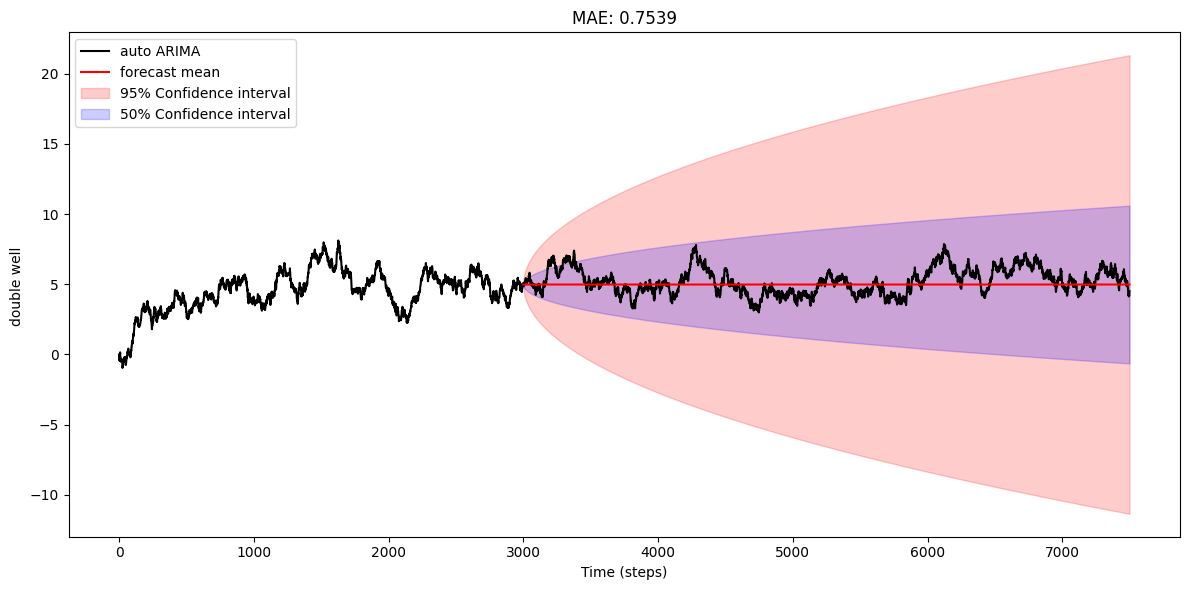

In [5]:
model = auto_arima(train_data,suppress_warnings=True)

result = model.arima_res_

steps = len(data) - split
test = data.iloc[split:]

forecast_res = result.get_forecast(steps=steps)
ci95 = forecast_res.conf_int(alpha=0.05)
ci95.index = test.index

n_sim = 10
sims = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim.index = test.index
    sims.append(sim)

plt.figure(figsize=(12, 6))

#num_trajs=4
#for _ in range(num_trajs):
#    plt.plot(data.index, x[np.random.randint(0,num_of_simulations)].detach().cpu().numpy(), color="black")    

plt.plot(data.index, data, color="black", label="auto ARIMA")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

#for sim in sims:
    #plt.plot(sim.index,sim,color="orange",alpha=0.5,label="Simulations" if n_sim == 1 else None)

plt.fill_between(ci95.index, ci95.iloc[:, 0], ci95.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index
plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.title(f'MAE: {mean_absolute_error(test, forecast_res.predicted_mean):.4f}')
          #\n mean MAE: {meanMAE(data.iloc[split:], sims):.4f}\n {mean_absolute_error(data.iloc[split:], sims[0]):.4f}')
plt.xlabel("Time (steps)")
plt.ylabel("double well ")
plt.legend()
plt.tight_layout()
plt.show()


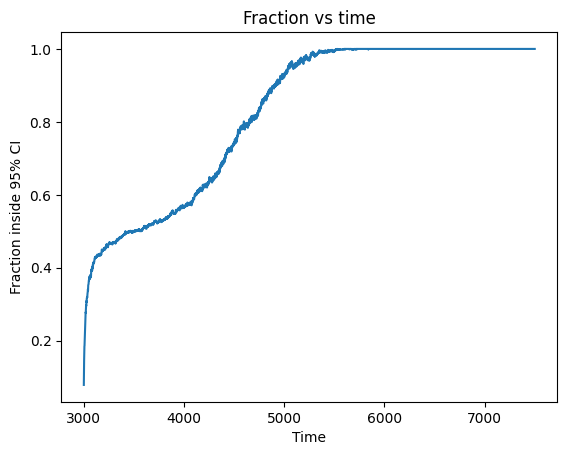

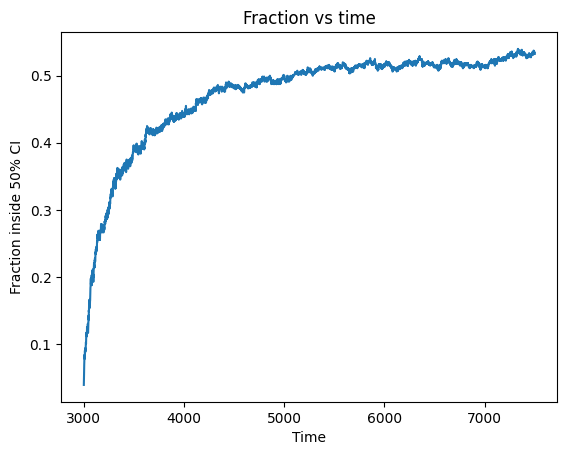

In [6]:
ci_lower = torch.tensor(ci95.iloc[:, 0].values)
ci_upper = torch.tensor(ci95.iloc[:, 1].values)

values=utils.fractionMetric(x[:,split:], ci_lower=ci_lower,ci_upper=ci_upper)

#print(values.dim())

plt.plot(test.index, values.detach().cpu().numpy())
plt.ylabel("Fraction inside 95% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

values=utils.fractionMetric(x[:,split:], ci_lower=torch.tensor(ci50.iloc[:, 0].values),ci_upper=torch.tensor(ci50.iloc[:, 1].values))

plt.plot(test.index, values.detach().cpu().numpy())
plt.ylabel("Fraction inside 50% CI")
plt.xlabel("Time")
plt.title("Fraction vs time")
plt.show()

In [7]:
n_sim = 200
sim_preds = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim_preds.append(torch.tensor(sim.values))

preds=torch.stack(sim_preds)
preds = preds.T    
target = torch.tensor(test.values)

crps_values = continuous_ranked_probability_score(preds, target)

crps_per_time=[]
for t in range(preds.shape[0]):
    crps_per_time.append(continuous_ranked_probability_score(preds[t].unsqueeze(0),target[t].unsqueeze(0)).detach().cpu().numpy())
plt.figure(figsize=(10, 4))
plt.plot(test.index, crps_per_time, color="purple")
plt.xlabel("Time")
plt.ylabel("CRPS")
plt.title("CRPS vs time")
plt.tight_layout()
plt.show()

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.34 GiB. GPU 0 has a total capacity of 3.63 GiB of which 1.20 GiB is free. Process 7289 has 2.32 GiB memory in use. Including non-PyTorch memory, this process has 106.00 MiB memory in use. Of the allocated memory 43.99 MiB is allocated by PyTorch, and 2.01 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)